# 共享单车用户 RFM 分层 - Part 2：聚类 (C4-C5)

读取 Part 1 的 `../data/rfm_standardized.csv`
运行后生成 `../data/rfm_clustered.csv`

### 读取 Part 1 数据

In [6]:
# ============================================================
# 读取 C1-C3 的输出文件
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
import warnings; warnings.filterwarnings("ignore")

# 读取标准化数据
rfm_data = pd.read_csv("../data/rfm_standardized.csv")
print(f"读取数据: {rfm_data.shape[0]} 用户")

# 构造 rfm 表（含原始 R/F/M 和标准化 R_SC/F_SC/M_SC）
rfm = rfm_data[["userid", "R", "F", "M", "R_SC", "F_SC", "M_SC"]].copy()

# 提取聚类特征矩阵 X = [R_SC, F_SC, M_SC]
X = rfm[["R_SC", "F_SC", "M_SC"]].values
print(f"聚类特征矩阵: {X.shape}")
rfm.head()

读取数据: 16883 用户
聚类特征矩阵: (16883, 3)


,userid,R,F,M,R_SC,F_SC,M_SC
0,1,0,5,7.18,-0.785969,-0.303232,-0.349462
1,3,3,8,8.49,-0.216845,0.559841,-0.145867
2,6,0,2,2.58,-0.785969,-1.166304,-1.064376
3,7,6,8,10.49,0.352280,0.559841,0.164965
4,8,4,7,7.09,-0.027136,0.272150,-0.363449


### C4 确定最佳 K 值

In [5]:
# ============================================================
# 遍历 K=2~10，计算 Inertia 和轮廓系数
# 先输出数据表，再分别画图
# ============================================================
X = rfm[["R_SC", "F_SC", "M_SC"]].values   # 特征矩阵

inertias = []           # 簇内平方和（越小越紧凑）
silhouette_scores = []  # 轮廓系数（越接近 1 质量越好）
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(sil)

# 输出汇总表
result_df = pd.DataFrame({
    "K": list(k_range),
    "Inertia（簇内平方和）": inertias,
    "Silhouette（轮廓系数）": silhouette_scores
})
result_df["Inertia（簇内平方和）"] = result_df["Inertia（簇内平方和）"].astype(int)
result_df["Silhouette（轮廓系数）"] = result_df["Silhouette（轮廓系数）"].round(4)
print("K=2~10 聚类评估指标汇总：")
result_df


K=2~10 聚类评估指标汇总：


,K,Inertia（簇内平方和）,Silhouette（轮廓系数）
0,2,28993,0.3909
1,3,19062,0.4165
2,4,14328,0.3618
3,5,12364,0.3116
4,6,10516,0.3178
5,7,9309,0.3238
6,8,8438,0.2990
7,9,7790,0.2926
8,10,7211,0.2947


**手肘图**

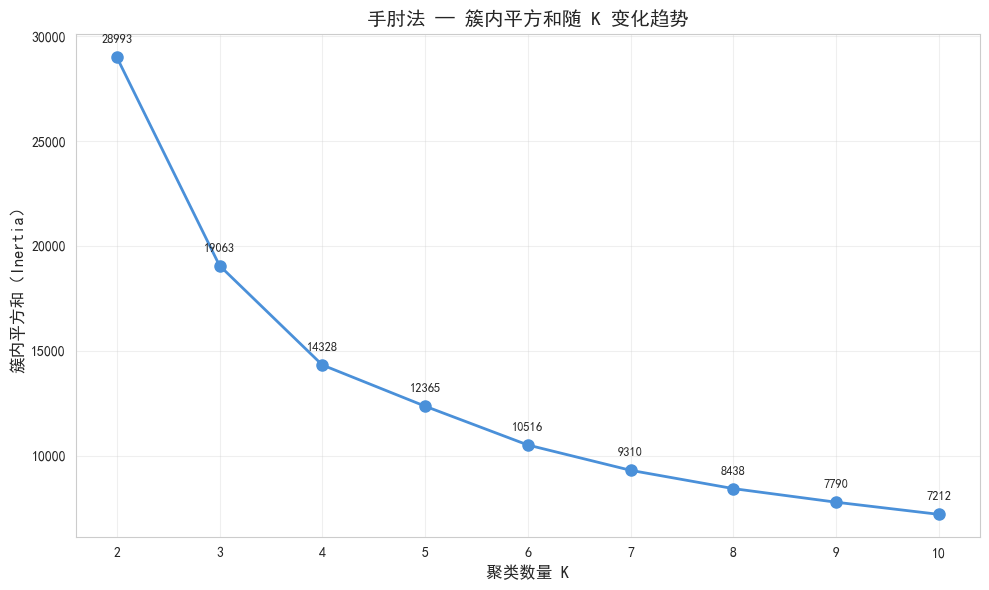

In [7]:
# ============================================================
# 图表：手肘法 — Inertia 随 K 变化
# "肘点"处 K 值即为推荐聚类数
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(list(k_range), inertias, "o-", color="#4A90D9", linewidth=2, markersize=8)
ax.set_xlabel("聚类数量 K", fontsize=12)
ax.set_ylabel("簇内平方和（Inertia）", fontsize=12)
ax.set_title("手肘法 — 簇内平方和随 K 变化趋势", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)

# 在每个点上方标注数值
for k_val, inertia in zip(k_range, inertias):
    ax.annotate(f"{inertia:.0f}", (k_val, inertia),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9)

plt.tight_layout()
plt.show()


**轮廓系数图**

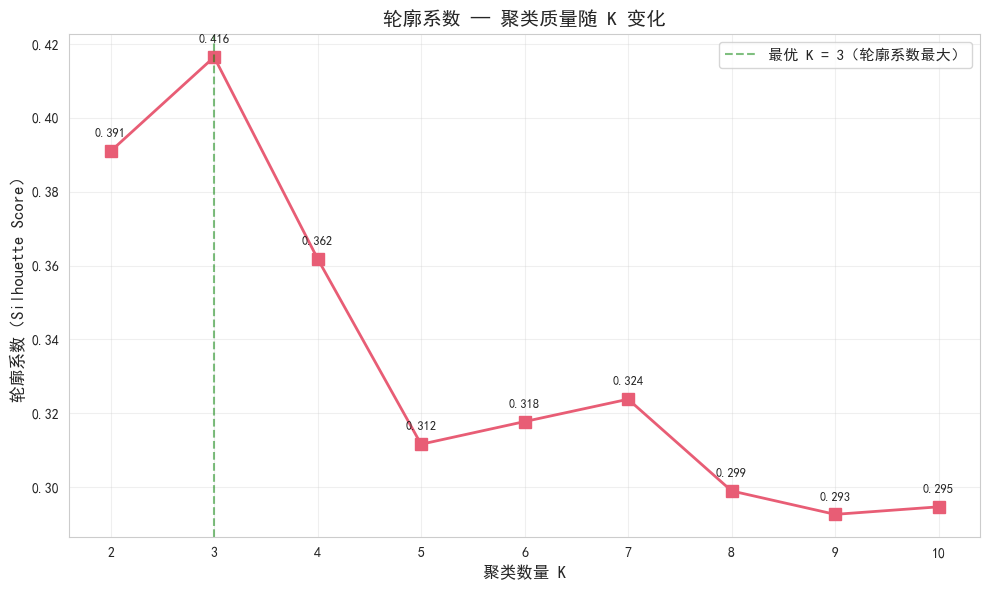

In [8]:
# ============================================================
# 图表：轮廓系数 — 聚类质量评估
# 轮廓系数最大值对应的 K 为最优聚类数
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(list(k_range), silhouette_scores, "s-", color="#E85D75", linewidth=2, markersize=8)
ax.set_xlabel("聚类数量 K", fontsize=12)
ax.set_ylabel("轮廓系数（Silhouette Score）", fontsize=12)
ax.set_title("轮廓系数 — 聚类质量随 K 变化", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)

# 标注最优 K
best_k_sil = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
ax.axvline(best_k_sil, color="green", linestyle="--", alpha=0.5,
           label=f"最优 K = {best_k_sil}（轮廓系数最大）")
ax.legend(fontsize=11)

for k_val, sil in zip(k_range, silhouette_scores):
    ax.annotate(f"{sil:.3f}", (k_val, sil),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9)

plt.tight_layout()
plt.show()


### C5 K-Means 聚类

### C5 K-Means 聚类

**K 值选择结论**：

- 手肘图中 Inertia 下降在 K 增大时逐渐趋于平缓
- 轮廓系数在 K 取某值时达到最大
- 代码根据**轮廓系数最大值**自动选择最优 K
- 运行下方代码即可看到具体选择的 K 值及依据


In [9]:
# ============================================================
# 根据轮廓系数自动选择最优 K，并训练最终模型
# ============================================================
# 在所有 K 值中，取轮廓系数最大的那个作为最优 K
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]

print("=" * 50)
print("K 值选择结论")
print("=" * 50)
print(f"候选 K 范围: 2 ~ 10")
print(f"选择依据:   轮廓系数（Silhouette Score）最大")
print(f"最优 K 值:   {best_k}")
print(f"对应轮廓系数: {max(silhouette_scores):.4f}")
print()
print("解读：轮廓系数越接近 1，聚类紧密度和分离度越好。")
print(f"      K={best_k} 时轮廓系数最高，故选择将用户分为 {best_k} 类。")
print("=" * 50)
print()

# 训练最终模型（n_init=20 跑 20 次选最优）
final_kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=42)
cluster_labels = final_kmeans.fit_predict(X)

# 最终模型聚合质量
avg_sil = silhouette_score(X, cluster_labels)
print(f"最终模型轮廓系数: {avg_sil:.4f}")

# 标注簇标签
rfm["cluster"] = cluster_labels

# 各簇用户分布
print()
print("各簇用户数量：")
cluster_counts = rfm["cluster"].value_counts().sort_index()
for cid, cnt in cluster_counts.items():
    print(f"  簇 {cid}: {cnt:6d} 人  ({cnt / len(rfm) * 100:5.1f}%)")


K 值选择结论
候选 K 范围: 2 ~ 10
选择依据:   轮廓系数（Silhouette Score）最大
最优 K 值:   3
对应轮廓系数: 0.4165

解读：轮廓系数越接近 1，聚类紧密度和分离度越好。
      K=3 时轮廓系数最高，故选择将用户分为 3 类。

最终模型轮廓系数: 0.4161

各簇用户数量：
  簇 0:   5696 人  ( 33.7%)
  簇 1:   2174 人  ( 12.9%)
  簇 2:   9013 人  ( 53.4%)


## 保存聚类结果

In [10]:
# ============================================================
# 保存聚类结果
# ============================================================
output_path = "../data/rfm_clustered.csv"
rfm.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"已保存: {output_path}")
print(f"维度: {rfm.shape[0]} 行 x {rfm.shape[1]} 列")
print(f"各簇用户数:")
print(rfm["cluster"].value_counts().sort_index())
rfm.head()

已保存: ../data/rfm_clustered.csv
维度: 16883 行 x 8 列
各簇用户数:
cluster
0    5696
1    2174
2    9013
Name: count, dtype: int64


,userid,R,F,M,R_SC,F_SC,M_SC,cluster
0,1,0,5,7.18,-0.785969,-0.303232,-0.349462,2
1,3,3,8,8.49,-0.216845,0.559841,-0.145867,2
2,6,0,2,2.58,-0.785969,-1.166304,-1.064376,2
3,7,6,8,10.49,0.352280,0.559841,0.164965,0
4,8,4,7,7.09,-0.027136,0.272150,-0.363449,2
